# Système de recommandation agricole - Exploration des données

Ce notebook a pour but d'appréhender les différents documents CSV de l'entreprise.

### Libraires nécessaires

In [105]:
# Imports de base
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
# Imports sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#### Afficher toutes les colonnes d'un dataframe

## Chargement des données provenant du dossier "Agriculture CropYield Dataset"
### On retrouve uniquement le fichier crop_yield.csv

In [106]:
data_crop_yield = pd.read_csv("../data/raw/crop_yield.csv")

### Ce que nous avons dans le fichier.

In [107]:
data_crop_yield.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [108]:
data_crop_yield.shape

(1000000, 10)

**Agriculture CropYield Dataset (crop_yield.csv) est un jeu de données volumineux contenant des relevés granulaires** :
- Nous avons 10 colonnes pour 1 million de lignes. 
- Nous avons un détail de plusieurs informations par **grande région**, par type de **sol** et de **récolte**.
- On retrouve un détail des températures (en celsius), les types de fertilisant utilisé, d'irrigation utilsé, les conditions météos, le nombre de jour de récolte et le rendement en tonnes par hectare.

### Génération des statistiques descriptives

In [109]:
data_crop_yield.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


**On retouve 4 variables numériques** :
- On retrouve bien nos 1M de lignes.
- Pas d'alerte particulière sur Rainfall_mm / Temperature_Celsius / Days_to_Harvest.
- On voit des rendements négatifs dans le minimum pour Yield_tons_per_hectare - à analyser - réalisation d'une analyse.

#### Analyse de Yield_tons_per_hectare

/var/folders/_7/crqqrrwd7ll_32f8lmt0d12h0000gn/T/ipykernel_65210/2480552038.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=crops, showfliers=True)


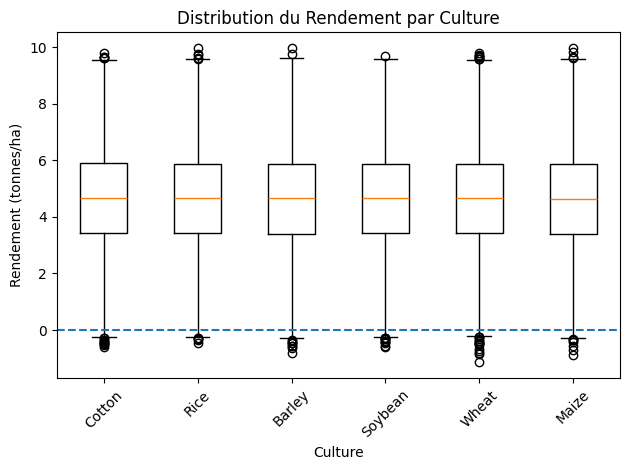

In [110]:
# Récupérer les cultures uniques
crops = data_crop_yield["Crop"].unique()
# Préparer les données pour chaque culture
data = [
    data_crop_yield[data_crop_yield["Crop"] == crop]["Yield_tons_per_hectare"]
    for crop in crops]
# Création du boxplot
plt.figure()
plt.boxplot(data, labels=crops, showfliers=True)
# Ligne horizontale à y = 0
plt.axhline(y=0, linestyle='--')
# Titres et labels
plt.title("Distribution du Rendement par Culture")
plt.xlabel("Culture")
plt.ylabel("Rendement (tonnes/ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Analyse du boxplot** :
- Nous avons croisé le rendement agricole avec le type de récolte pour identifier des valeurs aberrantes.
- Pour l'ensemble des types de récolte nous avons des valeurs négatives, ce qui est un non sens, il n'est pas logique d'avoir un rendement négatif.
- Certaines valeurs à l'inversent présentent des points très hauts (proches de 10 t/ha), bien que rare, ce n'est pas impossible si les conditions étaient parfaites (à vérifier également).


### Valeurs manquantes & valeurs en doublons

In [111]:
# Analyse des valeurs manquantes
data_crop_yield.isnull().mean()

Region                    0.0
Soil_Type                 0.0
Crop                      0.0
Rainfall_mm               0.0
Temperature_Celsius       0.0
Fertilizer_Used           0.0
Irrigation_Used           0.0
Weather_Condition         0.0
Days_to_Harvest           0.0
Yield_tons_per_hectare    0.0
dtype: float64

- Pas de valeurs manquantes identifiées

In [112]:
# Analyse des doublons
data_crop_yield.duplicated(keep=False).any()

np.False_

- Pas de doublons identifiés

In [113]:
data_crop_yield['Crop'].value_counts()

Crop
Maize      166824
Rice       166792
Barley     166777
Wheat      166673
Cotton     166585
Soybean    166349
Name: count, dtype: int64

### Distribution de notre variable cible

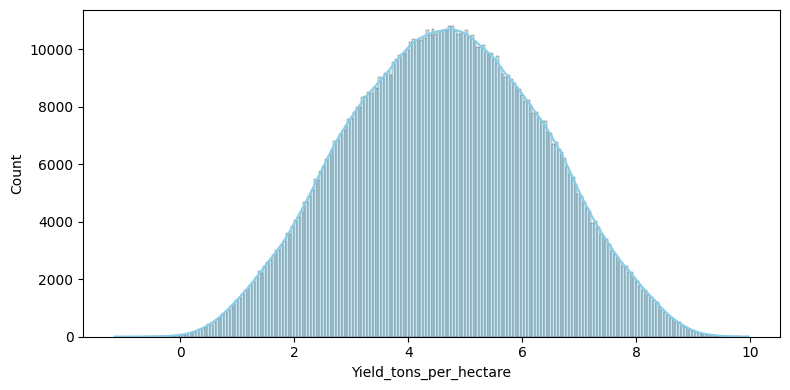

In [114]:
plt.figure(figsize=(8, 4))

# Histogramme + KDE
sns.histplot(data_crop_yield['Yield_tons_per_hectare'], kde=True, color="skyblue")
plt.tight_layout()
plt.show()

- Notre distribution ressemble à une cloche, donc à une distribution normale même si on ne peut pas la considérer comme telle car on voit quelques petits dépassements.


### Suppression des valeurs de rendement négatif
- Les valeurs extrêmes supérieurs ne sont pas des aberrations alors que les rendements négatifs si, aors on décide de les supperimer.

In [115]:
data_crop_yield_suppr = data_crop_yield.loc[data_crop_yield['Yield_tons_per_hectare']<0]
data_crop_yield_suppr.count()

Region                    231
Soil_Type                 231
Crop                      231
Rainfall_mm               231
Temperature_Celsius       231
Fertilizer_Used           231
Irrigation_Used           231
Weather_Condition         231
Days_to_Harvest           231
Yield_tons_per_hectare    231
dtype: int64

- On ne compte que 231 lignes en négatif. Sur 1M de lignes, on peut les supprimer.

In [116]:
data_crop_yield = data_crop_yield[data_crop_yield['Yield_tons_per_hectare'] >= 0]

In [117]:
data_crop_yield.shape

(999769, 10)

- On passe d'1 M de lignes à 999 769 lignes.

## Passons à l'ACP du fichier crop_yield
- L’ACP (Analyse en Composantes Principales) est une méthode statistique utilisée pour simplifier et analyser des données complexes.
- L’objectif de l’ACP est de réduire la dimension des données tout en conservant le maximum d’information (variance).

In [118]:
# Chargement des données
df = pd.read_csv("../data/raw/crop_yield.csv")

# Séparation des variables explicatives et de la variable cible
print("Colonnes :", df.columns.tolist())
print("================")
# Variable Cible
target_col = "Yield_tons_per_hectare"

# Variables explicatives numériques pour l'ACP
numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Days_to_Harvest"
]
# Nettoyage et vérification des doublons déjà effectué
# Matrice X pour l'ACP / Scaling
df_pca = df
X = df_pca[numeric_features].copy()

# Standardisation obligatoire avant ACP
# Uniquement sur les variables explicatives
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Moyennes après scaling :", X_scaled.mean(axis=0))
print("================")
print("Std après scaling :", X_scaled.std(axis=0))

Colonnes : ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']
Moyennes après scaling : [-6.73480827e-16 -5.98049610e-16 -9.04947228e-17 -5.88897819e-17
  6.74162948e-17]
Std après scaling : [1. 1. 1. 1. 1.]


In [119]:
# ACP complète
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
explained_variance = pca.explained_variance_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Tableau récapitulatif
pca_summary = pd.DataFrame({
    "Composante": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Variance expliquée": explained_variance_ratio,
    "Variance expliquée cumulée": cumulative_variance,
    "Valeur propre": explained_variance
})

print("\nRésumé ACP :")
print(pca_summary)


Résumé ACP :
  Composante  Variance expliquée  Variance expliquée cumulée  Valeur propre
0        PC1            0.200681                    0.200681       1.003405
1        PC2            0.200503                    0.401184       1.002515
2        PC3            0.200117                    0.601301       1.000586
3        PC4            0.199390                    0.800691       0.996953
4        PC5            0.199309                    1.000000       0.996546


- Ici l'ACP n'apporte pas de vraie réduction de dimension car elle est répartie sur l'ensemble des 5 composantes principales.
- Nous avons des variables indépendantes ou faiblement liés

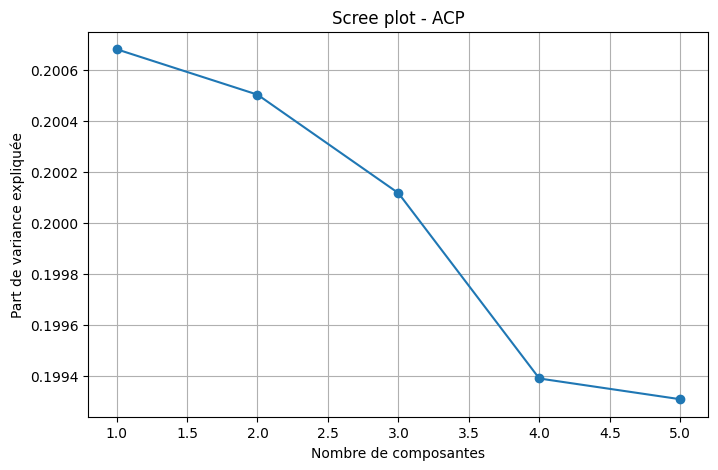

In [120]:
# Scree plot (variance expliquée)
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker="o"
)
plt.xlabel("Nombre de composantes")
plt.ylabel("Part de variance expliquée")
plt.title("Scree plot - ACP")
plt.grid(True)
plt.show()

In [121]:
# Intéressons nous maintenant à nos composantes. La formule de ce calcul nous est donnée par l'attribut components_ (cours OC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_features,
    columns=[f"PC{i+1}" for i in range(len(numeric_features))]
)

print("\nLoadings :")
print(loadings)


Loadings :
                          PC1       PC2       PC3       PC4       PC5
Rainfall_mm          0.148713  0.732539 -0.156174 -0.063207  0.642562
Temperature_Celsius  0.464414 -0.228489 -0.613502 -0.593931 -0.054533
Fertilizer_Used      0.593214 -0.385221 -0.030287  0.610778  0.354591
Irrigation_Used      0.363505 -0.106623  0.768398 -0.484670  0.176508
Days_to_Harvest     -0.527414 -0.501414 -0.088724 -0.187874  0.653644


**Même si l’ACP ne réduit pas beaucoup la dimension, elle reste très utile pour comprendre les relations.**

- PC1 :
    - conditions/intensité de croissance plus fortes” vs “cycle plus long
- PC2 :
    - PC2 est surtout un axe lié à la pluie, opposé à un bloc de variables agricoles/cycle
- PC3 :
    - irrigation vs température
- PC4 :
    - fertilisation et autres conditions de croissance
- PC5 : 
    - cycle plus long et environnement plus humide

<Axes: >

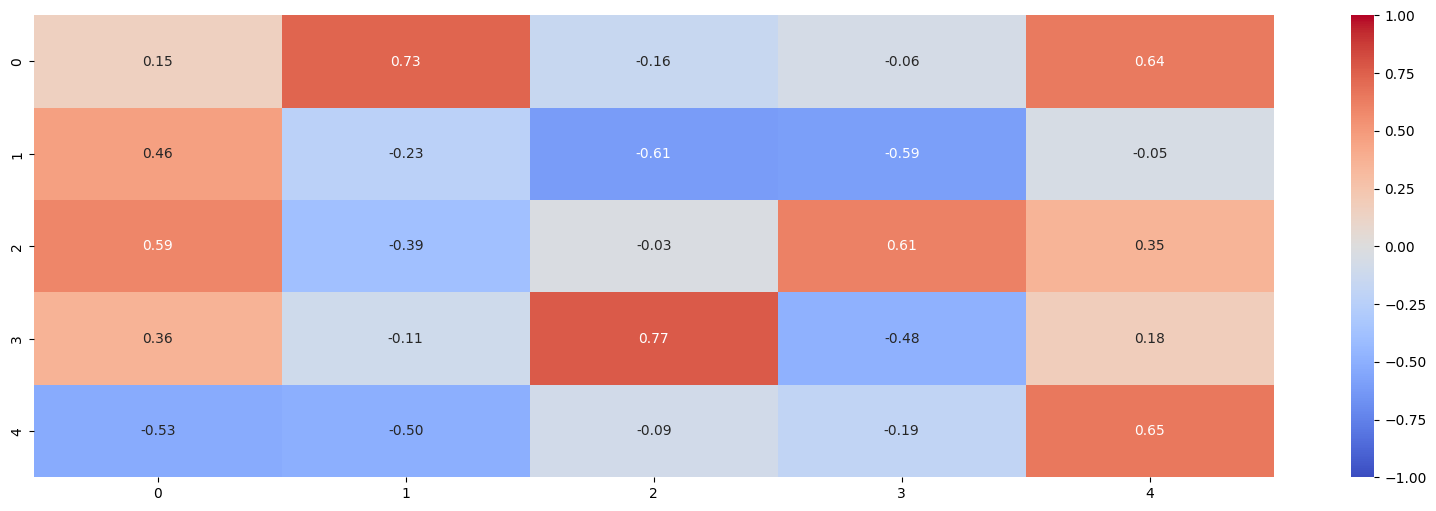

In [122]:
# Représentation plus visuelle
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pca.components_.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

        PC1       PC2     Crop  Yield_tons_per_hectare
0 -0.375292  0.913294   Cotton                6.555816
1 -0.120662  0.369979     Rice                8.527341
2 -1.069688 -0.743042   Barley                1.127443
3 -1.521228  1.051863  Soybean                6.517573
4  1.213246 -0.220040    Wheat                7.248251


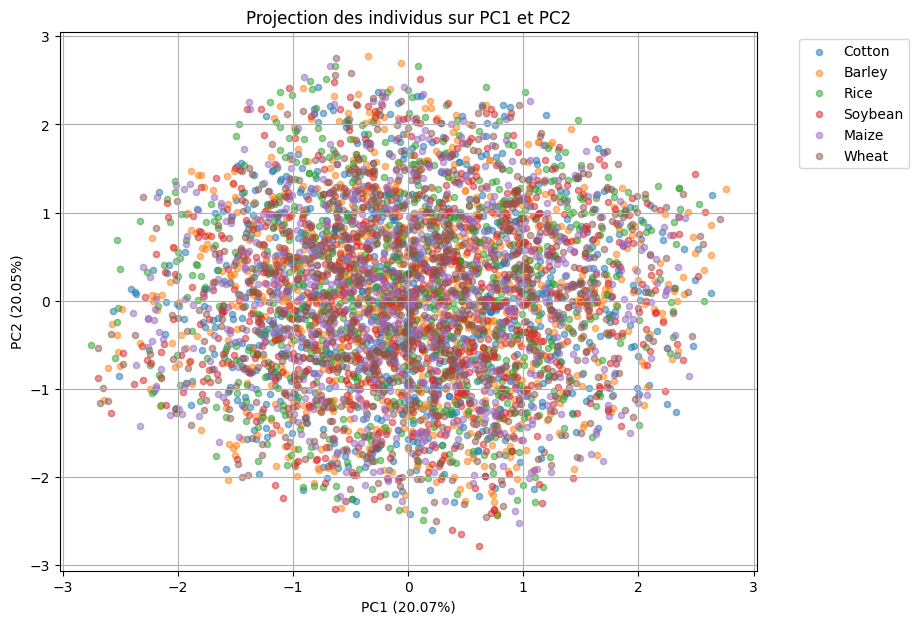

In [123]:
# Projection des individus
# Coordonnées des individus
scores = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)
scores["Crop"] = df_pca["Crop"].values
scores[target_col] = df_pca[target_col].values
print(scores.head())

# Pour éviter un graphe illisible sur 1M de lignes, on échantillonne
sample_size = min(5000, len(scores))
scores_sample = scores.sample(sample_size, random_state=42)

plt.figure(figsize=(9, 7))
for crop_name in scores_sample["Crop"].dropna().unique()[:10]:
    subset = scores_sample[scores_sample["Crop"] == crop_name]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.5, label=crop_name, s=20)

plt.xlabel(f"PC1 ({explained_variance_ratio[0]:.2%})")
plt.ylabel(f"PC2 ({explained_variance_ratio[1]:.2%})")
plt.title("Projection des individus sur PC1 et PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

- Il n’y a aucune séparation claire entre les cultures dans les 2 premières composantes
- Variables peu corrélées
- Pas de clusters naturels

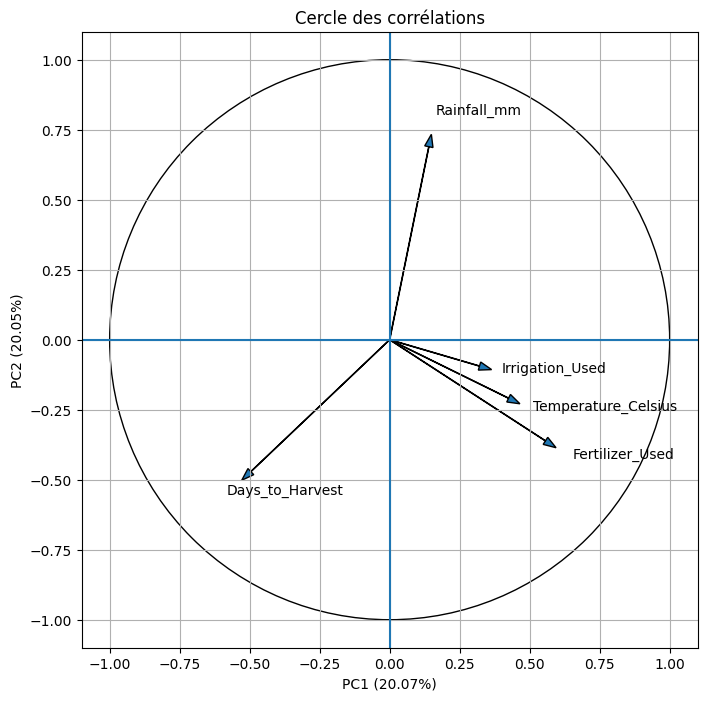

In [124]:
# Cercle des corrélations
correlation_circle = loadings.iloc[:, :2].copy()
correlation_circle["PC1"] = correlation_circle["PC1"] * np.sqrt(pca.explained_variance_[0])
correlation_circle["PC2"] = correlation_circle["PC2"] * np.sqrt(pca.explained_variance_[1])

plt.figure(figsize=(8, 8))

# Cercle unité
circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_artist(circle)

for var in correlation_circle.index:
    x = correlation_circle.loc[var, "PC1"]
    y = correlation_circle.loc[var, "PC2"]
    plt.arrow(0, 0, x, y, head_width=0.03, length_includes_head=True)
    plt.text(x * 1.1, y * 1.1, var, fontsize=10)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.axhline(0)
plt.axvline(0)
plt.xlabel(f"PC1 ({explained_variance_ratio[0]:.2%})")
plt.ylabel(f"PC2 ({explained_variance_ratio[1]:.2%})")
plt.title("Cercle des corrélations")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()


- Les variables alignées, elles pointent dans la même direction :
    - Fertilizer_Used
    - Temperature_Celsius
    - Irrigation_Used
    - Ces variables sont positivement corrélées entre elles
- Variable opposée : Days_to_Harvest est négativement correlé avec celles du dessus
    - plus d’engrais / température / irrigation = moins de jours jusqu’à récolte
- Variable isolée :
    - Rainfall : Rainfall est faiblement corrélée aux autres variables

- 3 dimensions réelles : intensité agricole / durée de culture / conditions climatiques

### Proxy
Un proxy est une variable qui remplace quelque chose qu'il ne peut pas être mesuré directement.

Variable, proxy de :
- Rainfall_mm : disponibilité en eau
- Irrigation_Used : gestion de l’eau
- Fertilizer_Used : fertilité du sol
- Temperature_Celsius : conditions climatiques
- pesticides_tonnes : intensité agricole

Les variables utilisées dans le modèle sont des proxies permettant d’approcher des phénomènes agronomiques complexes, tels que la disponibilité en eau ou la fertilité du sol.


## Chargement des données provenant du fichier "pesticides"

In [125]:
data_pesticides = pd.read_csv("../data/raw/pesticides.csv")

In [126]:
data_pesticides.head()

,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


### Informations du dataset

In [127]:
data_pesticides.info()

<class 'pandas.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domain   4349 non-null   str    
 1   Area     4349 non-null   str    
 2   Element  4349 non-null   str    
 3   Item     4349 non-null   str    
 4   Year     4349 non-null   int64  
 5   Unit     4349 non-null   str    
 6   Value    4349 non-null   float64
dtypes: float64(1), int64(1), str(5)
memory usage: 238.0 KB


In [128]:
data_pesticides.shape

(4349, 7)

Ici nous avons les informations concernant **l'utilisation de pesticide**. On a
- 5 variables non numériques
- 2 variables numériques
- La variable principale ici va être "Value" qui est la valeur en tonne de l'utilisation de pesticide

Le jeu se compose de 7 colonnes et 4349 lignes

### Génération des statistiques descriptives

In [129]:
data_pesticides.describe()

,Year,Value
count,4349.000000,4.349000e+03
mean,2003.138883,2.030334e+04
std,7.728044,1.177362e+05
min,1990.000000,0.000000e+00
25%,1996.000000,9.300000e+01
50%,2003.000000,1.137560e+03
75%,2010.000000,7.869000e+03
max,2016.000000,1.807000e+06


- A première vue nous ne voyons pas d'aberration statistique

#### Valeurs manquantes & doublons

In [130]:
data_pesticides.isnull().mean()

Domain     0.0
Area       0.0
Element    0.0
Item       0.0
Year       0.0
Unit       0.0
Value      0.0
dtype: float64

In [131]:
data_pesticides.duplicated(keep=False).any()

np.False_

In [132]:
data_pesticides.duplicated(['Area','Year']).any()

np.False_

- Pas de présence de valeurs manquantes ou de doublons

### Distibution de l'utilisation en tonne de pesticide

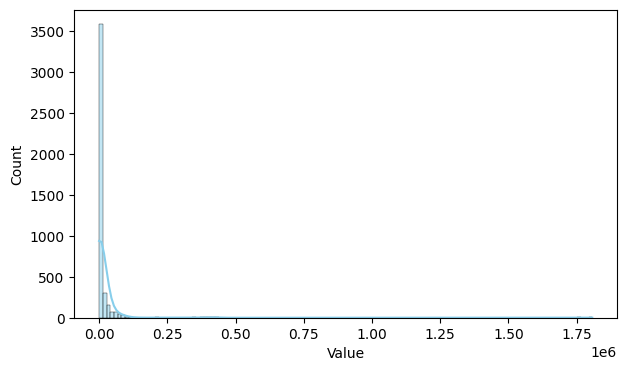

In [133]:
plt.figure(figsize=(7, 4))

# Histogramme + KDE
sns.histplot(data_pesticides['Value'], kde=True, color="skyblue")
plt.show()

- La distibution est étalée sur la gauche (pas dans le cadre d'une distribution normale), avec une importante concentration entre 0 et 0,1

### Relation entre la valeur en tonne des pesticides et l'année

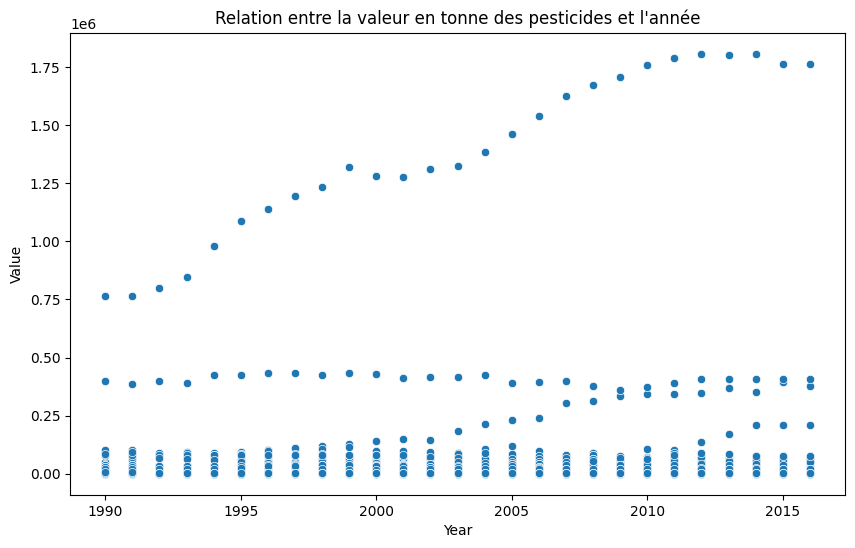

In [134]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_pesticides['Year'], y = data_pesticides['Value'])
plt.title("Relation entre la valeur en tonne des pesticides et l'année")
plt.show()

- Relation non linéaire
- On voit une concentration de l'utilisation de pestice évoluer de manière stable à travers le temps
- Cependant on remarque une augmentation croissante pour certaines valeurs (mais une minorité)
- On peut penser que les valeurs extrêmes sont des gros utilisateurs de pesticide et pas des valeurs aberrantes

### Valeurs extrêmes

In [135]:
# Nombre de tonnes total (sur l'ensemble des années)
print(f"Nombre de tonnes au global : {data_pesticides['Value'].sum()}")
top5_pays = (
    data_pesticides
    .groupby('Area')['Value']
    .sum()
    .nlargest(5)
)
# Nombre de tonnes sur le top5 en utilisant le plus (sur l'ensemble des années)
top5 = top5_pays.sum()
print(f"Nombre de tonnes du top 5 : {top5}")
print(f"% du top 5 sur le total : {round((top5/(data_pesticides['Value'].sum())*100),2)}%")
print(f"Détails du nombre de tonnes du top 5 : {top5_pays}")


Nombre de tonnes au global : 88299232.03
Nombre de tonnes du top 5 : 58343148.35
% du top 5 sur le total : 66.07%
Détails du nombre de tonnes du top 5 : Area
China, mainland             37194836.00
United States of America    10978289.10
Brazil                       5671552.00
Argentina                    2250064.53
France                       2248406.72
Name: Value, dtype: float64


- **Sur l'ensemble des années, le top 5 représente plus de 66% de la totalité d'utilisation des pesticides, ce gros écart peut expliquer les valeurs extrêmes vu dans le scatter plot.**

### Evolution globale des tonnes en pesticides par année

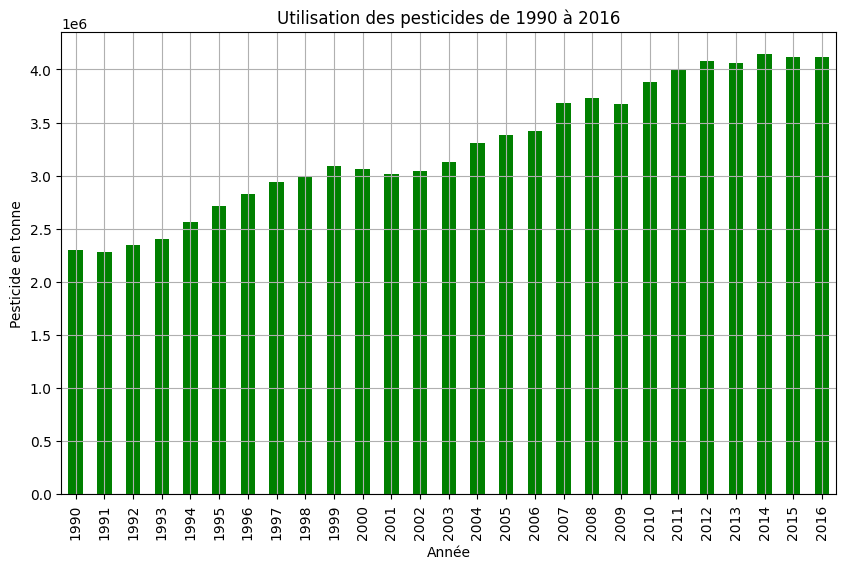

In [136]:
plt.figure(figsize=(10, 6))
hist_by_year = data_pesticides.groupby('Year')['Value'].sum()
hist_by_year.plot(kind='bar', color='green')
plt.title("Utilisation des pesticides de 1990 à 2016")
plt.xlabel('Année')
plt.ylabel("Pesticide en tonne")
plt.grid()

- Depuis les années 2000 jusqu'en 2006, on remarque une croissance de l'utilisation des pesticides de manière globale.
- Une petite en chute en 2009 avec une légère progression ensuite mais depuis 2011, l'utilisation reste constante.

### Nettoyage du fichier sur les pesticides

- Le travail ici va être simplement de sélectionner uniquement les variables importantes et en changeant les noms des variables pouvont porter à confusion

In [137]:
data_pesticides_renamed = data_pesticides.rename(
    columns = {'Value' : 'pesticides_tonnes'})
data_pesticides_clean = data_pesticides_renamed[['Area','Year','pesticides_tonnes']]
data_pesticides_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               4349 non-null   str    
 1   Year               4349 non-null   int64  
 2   pesticides_tonnes  4349 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 102.1 KB


## Chargement des données provenant du fichier "rainfall"

In [138]:
data_rainfall = pd.read_csv("../data/raw/rainfall.csv")

In [139]:
data_rainfall.head()

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


### Informations du dataset

In [140]:
data_rainfall.info()

<class 'pandas.DataFrame'>
RangeIndex: 6727 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0    Area                          6727 non-null   str  
 1   Year                           6727 non-null   int64
 2   average_rain_fall_mm_per_year  5953 non-null   str  
dtypes: int64(1), str(2)
memory usage: 157.8 KB


In [141]:
data_rainfall.shape

(6727, 3)

Ici nous avons les informations concernant **les précipitations en mm par an**. On a
- 2 variables non numériques
- 1 variable numérique
- La variable principale ici va être "average_rain_fall_mm_per_year" qui est la valeur en mm des précipitations
- **On voit tout de suite une première erreur, la moyenne des précipitations est en texte et non en numérique.**
- On voit également que le nom d'une des variables contient un espace

Le jeu se compose de 3 colonnes et 6726 lignes

### Génération des statistiques descriptives

In [142]:
data_rainfall.describe()

,Year
count,6727.000000
mean,2001.354839
std,9.530114
min,1985.000000
25%,1993.000000
50%,2001.000000
75%,2010.000000
max,2017.000000


### Valeurs manquantes & doublons

In [143]:
data_rainfall.isnull().mean()

 Area                            0.000000
Year                             0.000000
average_rain_fall_mm_per_year    0.115059
dtype: float64

In [144]:
data_rainfall.duplicated(keep=False).any()

np.False_

In [145]:
data_rainfall.duplicated(['Year',' Area']).any()

np.False_

- La variable average_rain_fall_mm_per_year contient des valeurs manquantes, ce qui explique aussi son erreur de format.
- Pas de doublons identifiés

### Analyse des valeurs manquantes

In [146]:
# Identification des pays avec des valeurs nulles
countries = data_rainfall.loc[
    data_rainfall['average_rain_fall_mm_per_year'].isnull(),
    ' Area'
].unique()
print(f"Liste des pays avec des valeurs nulles : \n{countries}")
print("\n============================\n")
# Récupération des pays où il y a au moins une valeur non nulle
result = data_rainfall.loc[
    (data_rainfall[' Area'].isin(countries)) &
    (data_rainfall['average_rain_fall_mm_per_year'].notna())
]
print(f"Liste des pays avec au moins une valeur non nulle : \n{result}")

Liste des pays avec des valeurs nulles : 
<StringArray>
[           'American Samoa',                     'Aruba',
                   'Bermuda',    'British Virgin Islands',
            'Cayman Islands',           'Channel Islands',
                   'Curacao',             'Faroe Islands',
          'French Polynesia',                 'Gibraltar',
                 'Greenland',                      'Guam',
      'Hong Kong SAR, China',               'Isle of Man',
                    'Kosovo',          'Macao SAR, China',
                    'Monaco',             'New Caledonia',
  'Northern Mariana Islands',                'San Marino',
 'Sint Maarten (Dutch part)',  'St. Martin (French part)',
                     'Tonga',  'Turks and Caicos Islands',
     'Virgin Islands (U.S.)']
Length: 25, dtype: str


Liste des pays avec au moins une valeur non nulle : 
        Area  Year average_rain_fall_mm_per_year
4061  Monaco  1985                            ..


- On retouve 25 pays sans valeurs pour la variable des précipitations.
- Monaco a une valeur non nulle mais qui est ".." alors aucun de ses 25 pays comportent une information concernant les précipitations

### Nettoyage du fichier rainfall.csv

- On procède à une clarification des noms des variables
- On transforme la variable précipitation en numérique

In [147]:
# On modifie le nom de la colonne Area qui comporte un espace
# On renomme le nom de la varibale average.. pour que cela soit plus simple
data_rainfall_renamed = data_rainfall.rename(columns={
    ' Area':'Area',
    'average_rain_fall_mm_per_year':'rainfall_mm'
})
# =============================================
# On prend les pays avec des valeurs manquantes
#countries = data_rainfall.loc[
    #data_rainfall['average_rain_fall_mm_per_year'].isnull(),
    #' Area'
#].unique()
# Suppression des valeurs manquantes (25 pays ici)
#data_rainfall_notnull = data_rainfall_renamed.loc[
    #~data_rainfall_renamed['Area'].isin(countries)]

# En attendant de savoir si on les supprime, on garde les NaN
data_rainfall_renamed['rainfall_mm'] = pd.to_numeric(
    data_rainfall_renamed['rainfall_mm'],
    errors='coerce' # force les valeurs non numériques en NaN
)
data_rainfall_clean = data_rainfall_renamed

In [148]:
data_rainfall_clean.describe()

,Year,rainfall_mm
count,6727.000000,5947.000000
mean,2001.354839,1124.743232
std,9.530114,786.257365
min,1985.000000,51.000000
25%,1993.000000,534.000000
50%,2001.000000,1010.000000
75%,2010.000000,1651.000000
max,2017.000000,3240.000000


### Distribution des précipitations

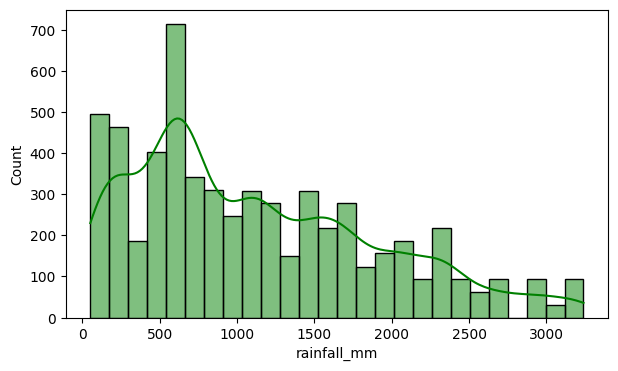

In [149]:
plt.figure(figsize=(7, 4))

# Histogramme + KDE
sns.histplot(data_rainfall_clean['rainfall_mm'], kde=True, color="green")
plt.show()

### Imputation par la moyenne des précipitations pour les 25 pays manquants

In [150]:
# Imputation simple des NaN par la moyenne globale car aucune information disponible
data_rainfall_clean["rainfall_mm"] = data_rainfall_clean["rainfall_mm"].fillna(
    data_rainfall_clean["rainfall_mm"].mean()
)

In [151]:
data_rainfall_clean.isnull().mean()

Area           0.0
Year           0.0
rainfall_mm    0.0
dtype: float64

- Plus de valeurs manquantes dans notre dataframe

## Chargement des données provenant du fichier "temp"

In [152]:
data_temp = pd.read_csv("../data/raw/temp.csv")

In [153]:
data_temp.head()

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


### Informations du dataset

In [154]:
data_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 71311 entries, 0 to 71310
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      71311 non-null  int64  
 1   country   71311 non-null  str    
 2   avg_temp  68764 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.6 MB


In [155]:
data_temp.shape

(71311, 3)

Ici nous avons les informations concernant **les températures**. On a
- 1 variable non numérique
- 2 variables numériques
- La variable principale ici va être "avg_temp" qui est la température moyenne par pays, par année

Le jeu se compose de 3 colonnes et 71311 lignes

In [156]:
duplicates = data_temp[data_temp.duplicated(keep=False)]
duplicates.head()

,year,country,avg_temp
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN
5,1854,Côte D'Ivoire,NaN
6,1855,Côte D'Ivoire,NaN
17,1866,Côte D'Ivoire,NaN


In [157]:
test_country = data_temp.loc[data_temp['country']=='Albania']
test_country.head()

,year,country,avg_temp
64138,1743,Albania,12.69
64139,1744,Albania,16.73
64140,1745,Albania,9.11
64141,1746,Albania,NaN
64142,1747,Albania,NaN


### Distribution température

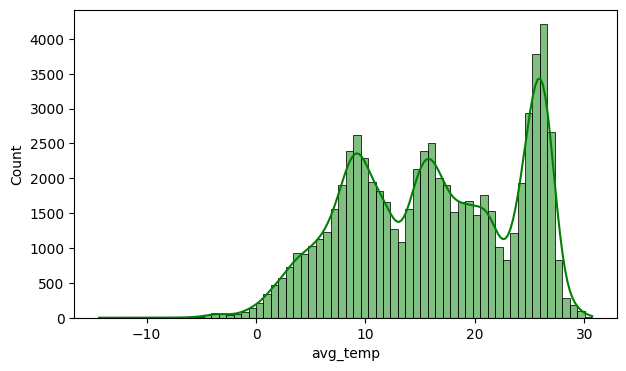

In [158]:
plt.figure(figsize=(7, 4))

# Histogramme + KDE
sns.histplot(data_temp['avg_temp'], kde=True, color="green")
plt.show()

- Étalement vers la droite, distribution non normale.
- On constate trois pics de température
- Les pays ayant un climat très différent, la distribution n'est pas choquante

### Génération des statistiques descriptives

In [159]:
data_temp.describe()

,year,avg_temp
count,71311.000000,68764.000000
mean,1905.799007,16.183876
std,67.102099,7.592960
min,1743.000000,-14.350000
25%,1858.000000,9.750000
50%,1910.000000,16.140000
75%,1962.000000,23.762500
max,2013.000000,30.730000


- On voit que nous avons la présence d'années très anciennes, avec un minimum à 1743, il faudra procéder à un tri.
- En terme de température, on va de -14 à 30 degrés, même si il ne paraît pas y avoir d'incohérence, on va quand même regarder les températures très basses.

#### Valeurs manquantes & doublons

In [160]:
data_temp.isnull().mean()

year        0.000000
country     0.000000
avg_temp    0.035717
dtype: float64

In [161]:
data_temp.duplicated(keep=False).any()

np.True_

- On retouve quelques valeurs manquantes pour les températures moyennes.
- On a également la présence de doublons.

### Il y a peu de valeurs manquantes.
- On pourrait se dire que cela est dû à la récupération de données très ancienne. Essayons de reprendre les valeurs manquantes à partir des années 1900.

In [162]:
data_year = data_temp.loc[data_temp['year']>1900]
data_year.isnull().mean()

year        0.0
country     0.0
avg_temp    0.0
dtype: float64

- Si nous prenons que les années à partir de 1900, nous avons plus de valeurs manquantes. Aucun autre dataset n'a des données aussi ancienne, alors on va choirsir cette règle.

In [163]:
data_temp_year = data_year

### Analyse des doublons

In [164]:
test_duplicated = data_temp_year.loc[data_temp_year.duplicated(keep=False)]
print(test_duplicated.head())
print(test_duplicated.count())

      year  country  avg_temp
412   1932  Nigeria     26.25
455   1975  Nigeria     25.89
479   1999  Nigeria     26.85
1169  1910    India     24.87
1187  1928    India     25.75
year        6140
country     6140
avg_temp    6140
dtype: int64


### Analyse d'un pays pour comprendre ce que nous avons

In [165]:
# Observons les doublons par année pour un pays par exemple
data_year = data_temp.loc[data_temp['year']>1990]
data_country = data_year.loc[data_year['country']=="Nigeria",["avg_temp","year"]].sort_values(by=["year"])
data_country.head(16)

,avg_temp,year
471,26.39,1991
38480,28.37,1991
29839,26.12,1991
26717,26.61,1991
34333,26.88,1991
30161,26.43,1991
51240,26.80,1991
38481,27.87,1992
472,26.08,1992
29840,25.76,1992


- Nous ne savons pas pourquoi il y a plusieurs moyennes de température par année, alors nous pouvons faire la moyenne des températures par année et par pays. Car on ne sait pas quelle donnée est la bonne pour en choisir qu'une.

### Afin d'avoir un dataset propre, nous prenons la moyenne par année et par pays pour ne plus avoir de doublons

In [166]:
temp_clean = (
    data_temp_year
    .groupby(['country', 'year'], as_index=False)['avg_temp']
    .mean()
)
temp_clean.head()


,country,year,avg_temp
0,Afghanistan,1901,14.11
1,Afghanistan,1902,14.68
2,Afghanistan,1903,13.35
3,Afghanistan,1904,14.18
4,Afghanistan,1905,13.61


In [167]:
# Test pour vérifier que cela a bien fonctionné
temp_clean.loc[(temp_clean["year"]==1991) & (temp_clean["country"]=="Nigeria")]

,country,year,avg_temp
10373,Nigeria,1991,26.8


### On renomme deux variables

In [168]:
temp_clean = temp_clean.rename(columns={"country":"Area", "year":"Year"})

## Chargement des données provenant du fichier "yield_df"

In [169]:
data_yield_df = pd.read_csv("../data/raw/yield_df.csv")

In [170]:
data_yield_df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


### Informations du dataset

In [171]:
data_yield_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


In [172]:
data_yield_df.shape

(28242, 8)

Ici nous avons les informations regroupant les informations des trois datasets vu juste au dessus. On a
- 2 variables non numériques
- 6 variables numériques
- Les variables principales sont la tempétaure, les précipitations et les tonnes de pesticides

Le jeu se compose de 8 colonnes et 28242 lignes.

- **Nous décidons de ne pas partir de ce fichier pour les analyses car nous ne savons pas comment a été réalisé les différentes imputations, fusions etc**

### Génération des statistiques descriptives

In [173]:
data_yield_df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


#### Valeurs manquantes & doublons

In [174]:
data_yield_df.isnull().mean()

Unnamed: 0                       0.0
Area                             0.0
Item                             0.0
Year                             0.0
hg/ha_yield                      0.0
average_rain_fall_mm_per_year    0.0
pesticides_tonnes                0.0
avg_temp                         0.0
dtype: float64

In [175]:
data_yield_df.duplicated(keep=False).any()

np.False_

In [176]:
data_yield_df.duplicated(['Area','Item','Year']).any()

np.True_

- Il y a bien eu une gestion des valeurs manquantes mais nous ne connaissons pas la méthodologie.
- On peut noter qu'il y a des doublons d'informations. Répetition en terme d'année par exemple.

### Exemple de duplication

In [177]:
duplicate_india =data_yield_df.loc[data_yield_df['Area']=='India']
duplicate_india.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
10502,10502,India,Cassava,1990,205381,1083.0,75000.0,25.58
10503,10503,India,Cassava,1990,205381,1083.0,75000.0,26.88
10504,10504,India,Cassava,1990,205381,1083.0,75000.0,25.79
10505,10505,India,Cassava,1990,205381,1083.0,75000.0,24.10
10506,10506,India,Cassava,1990,205381,1083.0,75000.0,25.25


- On voit ici par exemple pour l'Inde plusieurs température pour la même année, sur la même culture, cela fausse nos données.

## Chargement des données provenant du fichier "yield"

In [178]:
data_yield = pd.read_csv("../data/raw/yield.csv")

In [179]:
data_yield.head()

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


### Informations du dataset

In [180]:
data_yield.info()

<class 'pandas.DataFrame'>
RangeIndex: 56717 entries, 0 to 56716
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Domain Code   56717 non-null  str  
 1   Domain        56717 non-null  str  
 2   Area Code     56717 non-null  int64
 3   Area          56717 non-null  str  
 4   Element Code  56717 non-null  int64
 5   Element       56717 non-null  str  
 6   Item Code     56717 non-null  int64
 7   Item          56717 non-null  str  
 8   Year Code     56717 non-null  int64
 9   Year          56717 non-null  int64
 10  Unit          56717 non-null  str  
 11  Value         56717 non-null  int64
dtypes: int64(6), str(6)
memory usage: 5.2 MB


In [181]:
data_yield.shape

(56717, 12)

Ici nous avons les informations concernant **le rendement** par pays, années et par culture. On a
- 6 variables non numériques
- 6 variables numériques
- La variable principale ici va être "Value" qui est la valeur du rendement.
- On y voit déjà des colonnes inutiles d'un point de vu métier comme Area Code / Element Code / Element / Item Code ou encore Year Code

Le jeu se compose de 12 colonnes et 56717 lignes

- **C'est le fichier central du dossier des Prédictions, nous allons fusionner les données des trois autres fichiers avec celui-ci.**

### Génération des statistiques descriptives

In [182]:
data_yield.describe()

,Area Code,Element Code,Item Code,Year Code,Year,Value
count,56717.000000,56717.0,56717.000000,56717.000000,56717.000000,56717.000000
mean,125.650422,5419.0,111.611651,1989.669570,1989.669570,62094.660084
std,75.120195,0.0,101.278435,16.133198,16.133198,67835.932856
min,1.000000,5419.0,15.000000,1961.000000,1961.000000,0.000000
25%,58.000000,5419.0,56.000000,1976.000000,1976.000000,15680.000000
50%,122.000000,5419.0,116.000000,1991.000000,1991.000000,36744.000000
75%,184.000000,5419.0,125.000000,2004.000000,2004.000000,86213.000000
max,351.000000,5419.0,489.000000,2016.000000,2016.000000,1000000.000000


#### Valeurs manquantes & doublons

In [183]:
data_yield.isnull().mean()

Domain Code     0.0
Domain          0.0
Area Code       0.0
Area            0.0
Element Code    0.0
Element         0.0
Item Code       0.0
Item            0.0
Year Code       0.0
Year            0.0
Unit            0.0
Value           0.0
dtype: float64

In [184]:
data_yield.duplicated(keep=False).any()

np.False_

In [185]:
data_yield.duplicated(['Area','Item','Year']).any()

np.False_

- Pas de présence de valeurs manquantes ou de doublons

Un des plus gros travail ici va d'essayer d'être le plus cohérent possible :

- Utiliser des noms de varibales plus explicites
- Choisir une temporalité bien définit (les 20 années les plus récentes ?)

Pour ce faire nous devons rationaliser par rapport aux autres fichiers, nous vaons plusieurs problématiques :

- La temporalité n'est pas identique sur l'ensemble des datasets
- Le noms des pays semblent différent pour certains d'entres eux
- Première chose à faire va être de sélectionner une temporalité restreinte, on va sélectionner à partir de l'année 1990
- Deuxième chose à faire va être d'identifier les noms des pays à changer, seulement ceux qui vont nous paraître les plus évidents (pour ne pas se perdre dans ce sujet)

### Identification des pays à modifier

In [186]:
country_map = {
    # Afrique
    "Côte d'Ivoire": "Cote d'Ivoire",
    "United Republic of Tanzania": "Tanzania",

    # Moyen-Orient
    "Iran (Islamic Republic of)": "Iran",
    "Syrian Arab Republic": "Syria",

    # Europe / ex-URSS
    "Russian Federation": "Russia",
    "Republic of Moldova": "Moldova",

    # Amérique latine
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",

    # Asie
    "Viet Nam": "Vietnam",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",

    # Chine
    "China, mainland": "China",
    "China, Taiwan Province of": "Taiwan",
    "China, Hong Kong SAR": "Hong Kong",

    # USA
    "United States of America": "United States",

    # Europe
    "Czechia": "Czech Republic"
}

### Changement de nom des pays

In [187]:
for df in [data_yield, temp_clean, data_rainfall_clean, data_pesticides_clean]:
    df["Area"] = df["Area"].replace(country_map)

### Sélection dans le fichier yield, uniquement la temporalité à partir de 1990

In [188]:
data_yield = data_yield.loc[data_yield['Year']>1990]

## Fusion des datasets dans le fichier yield global

In [189]:
# Dataset à prendre en compte
temp_clean
data_rainfall_clean
data_pesticides_clean.head()

,Area,Year,pesticides_tonnes
0,Albania,1990,121.0
1,Albania,1991,121.0
2,Albania,1992,121.0
3,Albania,1993,121.0
4,Albania,1994,201.0


In [190]:
# Enregistrement du fichier global
df_predictions = data_yield

# Fusion du dataset température
yield_temp = df_predictions.merge(
    temp_clean,
    on=["Area", "Year"],
    how="left"
)
# Fusion du dataset précipitation
yield_temp_rain = yield_temp.merge(
    data_rainfall_clean,
    on=["Area", "Year"],
    how="left"
)
# Fusion final avec pesticide
yield_final = yield_temp_rain.merge(
    data_pesticides_clean,
    on=["Area", "Year"],
    how="left"
)

### Contrôle des valeurs manquantes

In [191]:
yield_final.isna().mean()

Domain Code          0.000000
Domain               0.000000
Area Code            0.000000
Area                 0.000000
Element Code         0.000000
Element              0.000000
Item Code            0.000000
Item                 0.000000
Year Code            0.000000
Year                 0.000000
Unit                 0.000000
Value                0.000000
avg_temp             0.390197
rainfall_mm          0.147931
pesticides_tonnes    0.169920
dtype: float64

### Imputation par la moyenne

In [192]:
# Ajout d'un flag pour identifier si il y a eu une imputation
yield_final["rainfall_missing"] = yield_final["rainfall_mm"].isna().astype(int)
yield_final["temp_missing"] = yield_final["avg_temp"].isna().astype(int)
yield_final["pesticides_missing"] = yield_final["pesticides_tonnes"].isna().astype(int)

In [193]:
# Imputation par la moyenne par pays par colonne
for col in ["rainfall_mm", "avg_temp", "pesticides_tonnes"]:
    yield_final[col] = yield_final.groupby("Area")[col].transform(
        lambda x: x.fillna(x.mean())
    )

In [194]:
# Imputation par la moyenne par colonne (si jamais il n'y avait pas de possibilité parpays)
for col in ["rainfall_mm", "avg_temp", "pesticides_tonnes"]:
    yield_final[col] = yield_final[col].fillna(yield_final[col].mean())

In [195]:
# Check des valeurs manquantes
yield_final.isnull().mean()

Domain Code           0.0
Domain                0.0
Area Code             0.0
Area                  0.0
Element Code          0.0
Element               0.0
Item Code             0.0
Item                  0.0
Year Code             0.0
Year                  0.0
Unit                  0.0
Value                 0.0
avg_temp              0.0
rainfall_mm           0.0
pesticides_tonnes     0.0
rainfall_missing      0.0
temp_missing          0.0
pesticides_missing    0.0
dtype: float64

### Check des doublons

In [196]:
yield_final.duplicated(['Area Code','Area','Year','Item']).any()

np.False_

### On garde uniquement les colonnes dont nous avons besoin

In [197]:
cols = ['Area','Area Code','Item','Year','Value','avg_temp','rainfall_mm','pesticides_tonnes']
yield_final = yield_final[cols]

### On sauvegarde le jeu de données yield final

In [198]:
yield_final.to_csv('../data/processed/yield_df_final.csv')

### On analyse de nouveau les statistiques descriptives

In [199]:
yield_final.describe()

,Area Code,Year,Value,avg_temp,rainfall_mm,pesticides_tonnes
count,28378.000000,28378.000000,28378.000000,28378.000000,28378.000000,2.837800e+04
mean,127.273169,2003.620586,69945.032314,19.689413,1212.192300,3.913429e+04
std,75.284880,7.472551,75581.348214,5.801207,729.034238,1.761208e+05
min,1.000000,1991.000000,0.000000,-3.370000,51.000000,0.000000e+00
25%,59.000000,1997.000000,18430.250000,17.350000,645.000000,2.646000e+02
50%,124.000000,2004.000000,40557.500000,19.689413,1180.000000,3.375530e+03
75%,188.000000,2010.000000,96508.250000,24.670000,1622.000000,3.913429e+04
max,351.000000,2016.000000,554855.000000,30.420000,3240.000000,1.807000e+06


- Pas d'incohérence majeure sur les variables rajoutées

### Analyse des corrélations sur le fichier yield
- Utilisation de la méthode spearman car nous ne sommes pas dans le cadre d'une distribution normale.

In [200]:
# Tableau des corrélations
cols_num = ['avg_temp','rainfall_mm','pesticides_tonnes','Value']
spearman_corr = yield_final[cols_num].corr(numeric_only=True, method='spearman')
spearman_corr

,avg_temp,rainfall_mm,pesticides_tonnes,Value
avg_temp,1.000000,0.324402,-0.222009,-0.095665
rainfall_mm,0.324402,1.000000,0.051594,0.035235
pesticides_tonnes,-0.222009,0.051594,1.000000,0.123998
Value,-0.095665,0.035235,0.123998,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

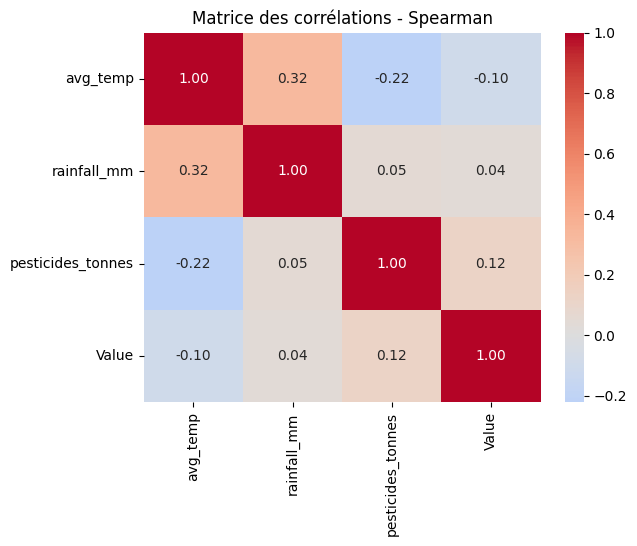

In [201]:
# Matrice des corrélations
sns.heatmap(spearman_corr, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title('Matrice des corrélations - Spearman')
plt.show

- On note une corrélation assez forte entre les températures moyennes et les précipitations
- Avec la valeur cible c'est la valeur des pesticides qui a un lien + fort que les autres
- Relation négative entre les températures et les pesticides ainsi qu'entre les rendements et les températures

### Visualtion du pairplot

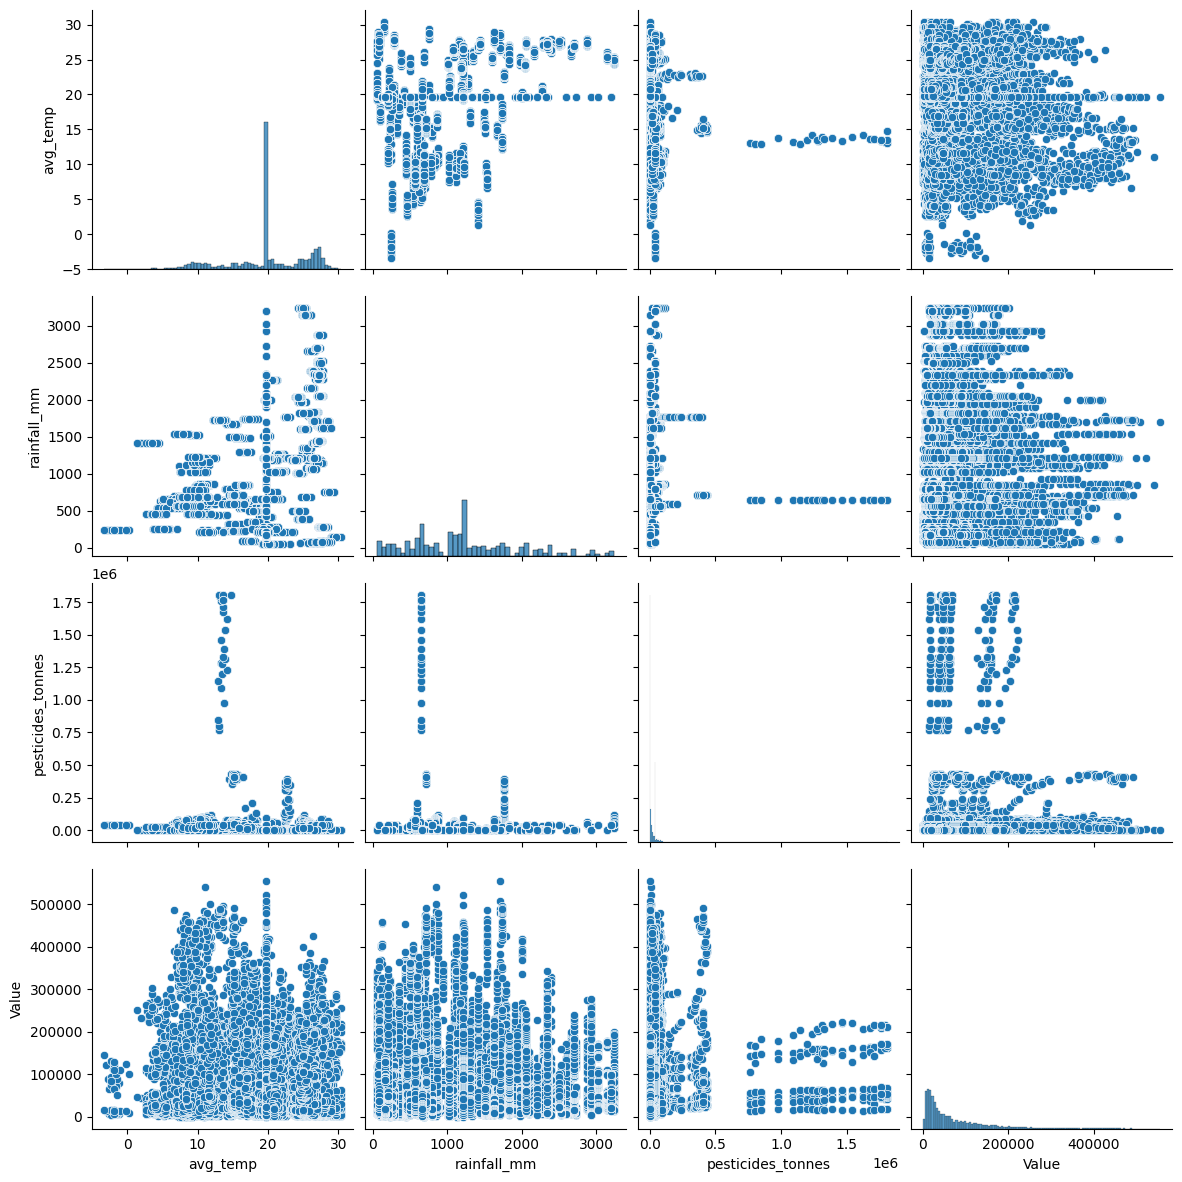

In [202]:
sns.pairplot(yield_final[cols_num], height=3)
plt.show()

# Comparaison ACP vs dataset prediction

L’ACP montre que la variance est répartie de manière homogène entre les composantes, ce qui indique l’absence de structure dominante et de fortes corrélations entre les variables explicatives.
La matrice de corrélation confirme ce constat, avec des coefficients globalement faibles, traduisant des relations linéaires limitées entre variables, ainsi qu’avec la variable cible.

# Fusion des deux fichiers

Il n'y a de relation directe entre notre premier dataset (celui pour l'ACP) et les autres datasets.
- Le premier fichier est par grande région et culture
- Le deuxième fichier est par pays, par année puis par culture
- Le rapprochement des données serait très bancal.